# new_run — spec → resolve → preflight → launch

Describe **only the target** (below, an `SFTJob`, which pulls in its own `PretrainJob`
as a dependency). The resolver backward-chains through `requires()` to enumerate every
job, dedupes by content-addressed uid, and writes `runs/{run_id}/config.json` with each
job's params, dependency uids, and the **actual files** it needs. Preflight
re-instantiates every class from the config (pydantic validates) and checks the config
matches the code before anything spawns.

In [ ]:
from pathlib import Path
import json, shutil

from jobs_LEGACY import (SourceJob, TokenizerTrainJob, TokenizeJob, PretrainJob, DataJob, SFTJob,
                  resolve, preflight, run_job)
from jobs_LEGACY import dag_svg, run_id_for
VOLUME = Path("volume")          # stand-in for the Modal volume mount
VOLUME.mkdir(exist_ok=True)

## 1. Spec — the only thing you write by hand

In [2]:
VOCAB_SIZE = 64

TRAIN_SET = ["odyssey", "mobydick"]
VALID_SET = ["montecristo", "romeojuliet"]
TOKEN_SET = ["odyssey","mobydick"]

def src(name):                     # expand a name into SourceJob params
    return {"name": name, "normalizer": "lowercase"}

# Every job spec is {"parameters": {...}}. A job-reference nested inside another
# job's parameters (like PRETRAIN's "tokenizer" below) holds another job's
# parameters the same way -- TOKENIZER["parameters"], not TOKENIZER itself.
TOKENIZER = {
    "parameters": {
        "vocab_size": VOCAB_SIZE,
        "kind": "bpe",
        "special_tokens": ["<|endoftext|>", "<|begin|>", "<|end|>"],
        "fit_sources": [src(n) for n in TOKEN_SET],
    },
}

PRETRAIN = {
    "parameters": {
        "model": {"n_layer": 2, "n_embd": 64, "lr": 3e-4, "epochs": 1},
        "tokenizer": TOKENIZER["parameters"],
        "train_sources": [src(n) for n in TRAIN_SET],
        "val_sources":   [src(n) for n in VALID_SET],
    },
}

SFT = {
    "parameters": {
        "pretrain": PRETRAIN["parameters"],
        "dataset": {"name": "chat_sft"},
        "lr": 1e-5,
        "epochs": 2,
    },
}


target = SFTJob(SFT)

In [7]:
PretrainJob(PRETRAIN).uid

'pretrain-67168c8642e0'

In [ ]:

SFT = {
    "parameters": {
        "pretrain": 'pretrain-67168c8642e0',
        "dataset": {"name": "chat_sft"},
        "lr": 1e-5,
        "epochs": 2,
    },
}


target = SFTJob(SFT)

'pretrain-67168c8642e0'

## 2. Resolve — backward-chain into a full plan

Note the dedup: `odyssey` is in both `TOKEN_SET` and `TRAIN_SET` but appears as
**one** SourceJob, feeding both the tokenizer fit and its own tokenize job.

In [3]:
from pygments import highlight, lexers, formatters
import json

print(json.dumps(resolve(target), indent=2))

{
  "target": "sft-c0ba4dc6bca1",
  "jobs": {
    "source-mobydick-033f1006eac3": {
      "metadata": {
        "job_type": "source",
        "code_version": "1"
      },
      "parameters": {
        "name": "mobydick",
        "normalizer": "lowercase"
      },
      "dependencies": [],
      "input_files": [],
      "outputs": [
        "data/sources/source-mobydick-033f1006eac3/content.txt"
      ]
    },
    "source-odyssey-94d437ee15c3": {
      "metadata": {
        "job_type": "source",
        "code_version": "1"
      },
      "parameters": {
        "name": "odyssey",
        "normalizer": "lowercase"
      },
      "dependencies": [],
      "input_files": [],
      "outputs": [
        "data/sources/source-odyssey-94d437ee15c3/content.txt"
      ]
    },
    "tokenizer-bpe-64-91eb85b4e3a1": {
      "metadata": {
        "job_type": "tok_train",
        "code_version": "1"
      },
      "parameters": {
        "kind": "bpe",
        "vocab_size": 64,
        "special_tokens

In [4]:
set(list(resolve(SFTJob(SFT))['jobs'].keys())) - set(list(resolve(PretrainJob(PRETRAIN))['jobs'].keys()))

{'data-cc6b72d62652', 'sft-c0ba4dc6bca1'}

In [5]:
config = resolve(target)
for uid, e in config["jobs"].items():
    print(f"{uid:28s} deps={len(e['dependencies'])}  inputs={len(e['input_files'])}")
print(f"\ntarget: {config['target']}   total jobs: {len(config['jobs'])}")

source-mobydick-033f1006eac3 deps=0  inputs=0
source-odyssey-94d437ee15c3  deps=0  inputs=0
tokenizer-bpe-64-91eb85b4e3a1 deps=2  inputs=2
tokenize-mobydick-1813d7a77e01 deps=2  inputs=2
tokenize-odyssey-015096fb4d5c deps=2  inputs=2
source-montecristo-f3fd4c9d30e2 deps=0  inputs=0
tokenize-montecristo-f8d481dc3a86 deps=2  inputs=2
source-romeojuliet-2160cc626638 deps=0  inputs=0
tokenize-romeojuliet-dbebd3f93288 deps=2  inputs=2
pretrain-67168c8642e0        deps=4  inputs=4
data-cc6b72d62652            deps=0  inputs=0
sft-c0ba4dc6bca1             deps=3  inputs=3

target: sft-c0ba4dc6bca1   total jobs: 12


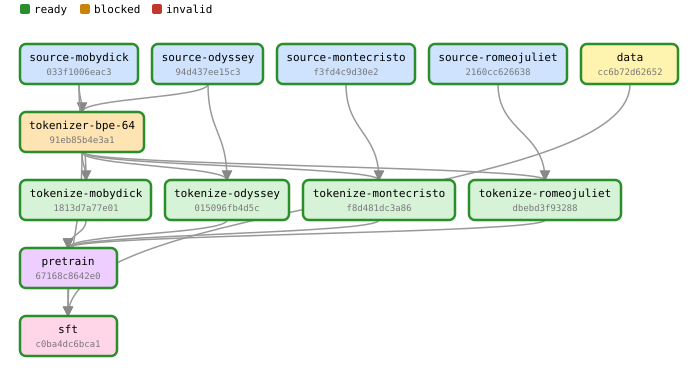

In [14]:
report = preflight(config, VOLUME)
dag_svg(config,report)  # box per job, colored by job_type; last line so Jupyter renders it

In [7]:
# What one entry looks like — dependencies as job uids AND as concrete files:
pretrain_uid = next(uid for uid, e in config["jobs"].items() if e["metadata"]["job_type"] == "pretrain")
print(json.dumps(config["jobs"][pretrain_uid], indent=2))

{
  "metadata": {
    "job_type": "pretrain",
    "code_version": "1"
  },
  "parameters": {
    "model": {
      "n_layer": 2,
      "n_embd": 64,
      "lr": 0.0003,
      "epochs": 1
    },
    "tokenizer": {
      "vocab_size": 64,
      "kind": "bpe",
      "special_tokens": [
        "<|endoftext|>",
        "<|begin|>",
        "<|end|>"
      ],
      "fit_sources": [
        {
          "name": "odyssey",
          "normalizer": "lowercase"
        },
        {
          "name": "mobydick",
          "normalizer": "lowercase"
        }
      ]
    },
    "train_sources": [
      {
        "name": "mobydick",
        "normalizer": "lowercase"
      },
      {
        "name": "odyssey",
        "normalizer": "lowercase"
      }
    ],
    "val_sources": [
      {
        "name": "montecristo",
        "normalizer": "lowercase"
      },
      {
        "name": "romeojuliet",
        "normalizer": "lowercase"
      }
    ]
  },
  "dependencies": [
    "tokenize-mobydick-1813d7a77e

## 3. Save the run — config.json under a unique run_id

In [8]:
run_id = run_id_for(config)      # deterministic: same target -> same run_id
run_dir = VOLUME / "runs" / run_id
run_dir.mkdir(parents=True, exist_ok=True)
(run_dir / "config.json").write_text(json.dumps(config, indent=2))
print("wrote", run_dir / "config.json")

wrote volume/runs/sft-c0ba4dc6bca1/config.json


## 4. Preflight — config ↔ class agreement + dependency existence

Every entry is re-instantiated from its `metadata.job_type` + `parameters`; pydantic
validates the params, and the recomputed uid / dependencies / input_files /
outputs must match what the config claims. `ready` means valid **and** all
input files exist on the volume — the launcher's no-spawn-before-deps gate.

In [9]:
report = preflight(config, VOLUME)
print("config valid:", report["ok"], "\n")
for uid, r in report["jobs"].items():
    state = "READY" if r["ready"] else "BLOCKED"
    print(f"{uid:28s} {state:8s} missing_inputs={len(r['missing_inputs'])}")

config valid: True 

source-mobydick-033f1006eac3 READY    missing_inputs=0
source-odyssey-94d437ee15c3  READY    missing_inputs=0
tokenizer-bpe-64-91eb85b4e3a1 READY    missing_inputs=0
tokenize-mobydick-1813d7a77e01 BLOCKED  missing_inputs=1
tokenize-odyssey-015096fb4d5c BLOCKED  missing_inputs=1
source-montecristo-f3fd4c9d30e2 READY    missing_inputs=0
tokenize-montecristo-f8d481dc3a86 BLOCKED  missing_inputs=1
source-romeojuliet-2160cc626638 READY    missing_inputs=0
tokenize-romeojuliet-dbebd3f93288 BLOCKED  missing_inputs=1
pretrain-67168c8642e0        BLOCKED  missing_inputs=4
data-cc6b72d62652            READY    missing_inputs=0
sft-c0ba4dc6bca1             BLOCKED  missing_inputs=2


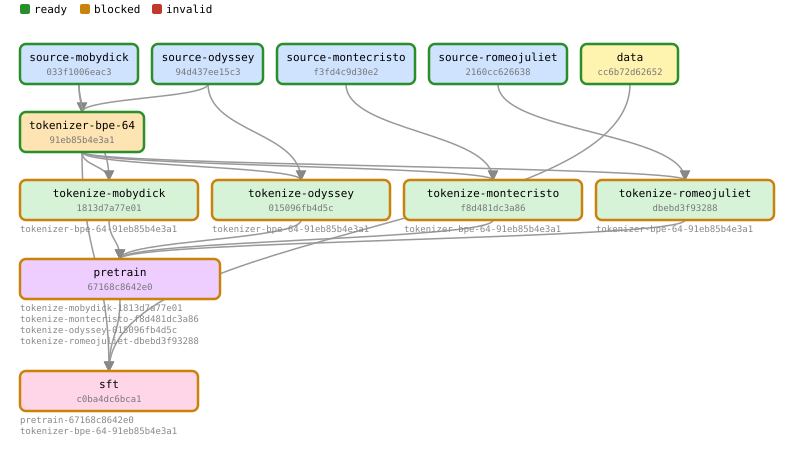

In [10]:
report = preflight(config, VOLUME)
dag_svg(config, report)  # same graph, outlined by preflight status: green ready, amber blocked, red invalid

## 5. Launch — each job gates on its own inputs

Trying the target job first is refused (this is the check that keeps a GPU
container from ever spawning early). Then we launch in topo order — exactly
what an auto-advancing launcher would do, one container per job.

source-mobydick-033f1006eac3: done -> ['data/sources/source-mobydick-033f1006eac3/content.txt']
source-odyssey-94d437ee15c3: done -> ['data/sources/source-odyssey-94d437ee15c3/content.txt']
tokenizer-bpe-64-91eb85b4e3a1: done -> ['data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/tokenizer.obj']
tokenize-mobydick-1813d7a77e01: done -> ['data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-mobydick-033f1006eac3.bin']
tokenize-odyssey-015096fb4d5c: done -> ['data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-odyssey-94d437ee15c3.bin']
source-montecristo-f3fd4c9d30e2: done -> ['data/sources/source-montecristo-f3fd4c9d30e2/content.txt']
tokenize-montecristo-f8d481dc3a86: done -> ['data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-montecristo-f3fd4c9d30e2.bin']
source-romeojuliet-2160cc626638: done -> ['data/sources/source-romeojuliet-2160cc626638/content.txt']
tokenize-romeojuliet-dbebd3f93288: done -> ['data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-romeojuliet-2160

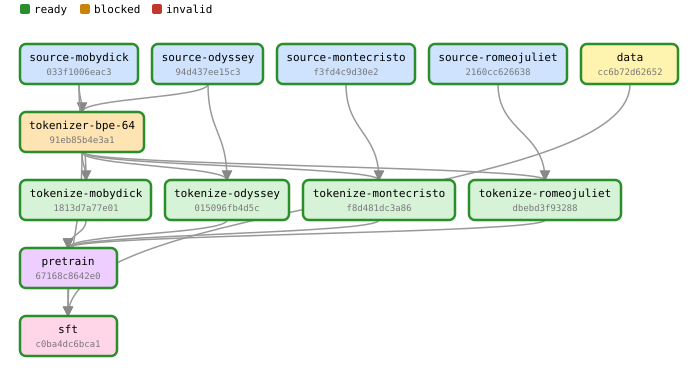

In [11]:
for uid in config["jobs"]:                 # topo order from the resolver
    print(run_job(VOLUME, config, uid))
report = preflight(config, VOLUME)
dag_svg(config, report)

## 6. Preflight catches drift

Tamper with a param in the config (as if the file were stale or hand-edited):
the recomputed uid no longer matches the entry's key, so the run is rejected
before any container spawns.

In [12]:
bad = json.loads(json.dumps(config))
first = next(iter(bad["jobs"]))
bad["jobs"][first]["parameters"]["name"] = "hacked"

r = preflight(bad, VOLUME)
print("config valid:", r["ok"])
print(r["jobs"][first]["issues"])

config valid: False
['uid mismatch: config=source-mobydick-033f1006eac3 class=source-hacked-3c1e063b7cb8', "outputs don't match class definition"]


In [13]:
# And the volume now looks exactly like your layout:
for p in sorted(VOLUME.rglob("*")):
    if p.is_file():
        print(p.relative_to(VOLUME))

data/datasets/data-cc6b72d62652/rows.json
data/sources/source-mobydick-033f1006eac3/content.txt
data/sources/source-montecristo-f3fd4c9d30e2/content.txt
data/sources/source-odyssey-94d437ee15c3/content.txt
data/sources/source-romeojuliet-2160cc626638/content.txt
data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-mobydick-033f1006eac3.bin
data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-montecristo-f3fd4c9d30e2.bin
data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-odyssey-94d437ee15c3.bin
data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/bin/source-romeojuliet-2160cc626638.bin
data/tokenizers/tokenizer-bpe-64-91eb85b4e3a1/tokenizer.obj
data/tokenizers/tokenizer-bpe-64-9c2580f0e443/bin/source-mobydick-033f1006eac3.bin
data/tokenizers/tokenizer-bpe-64-9c2580f0e443/bin/source-montecristo-f3fd4c9d30e2.bin
data/tokenizers/tokenizer-bpe-64-9c2580f0e443/bin/source-odyssey-94d437ee15c3.bin
data/tokenizers/tokenizer-bpe-64-9c2580f0e443/bin/source-romeojuliet-2160cc626638.bin
dat